# Truncation Diagnostic — Turn-Level Predictions

**Question:** Does DeBERTa's 512-token truncation introduce systematic bias in the disagreement analysis?

**Method:** Tokenize every turn with the `microsoft/deberta-v3-base` tokenizer *without* truncation
(no model weights needed — tokenizer only), flag turns where token count > 512 as truncated,
then compare split rates across groups.

**Key test:** Are truncated turns more or less likely to be *split* (LLM disagreement)?  
- If truncated turns have **lower** split rates → truncation bites on long, clearly-stanced content
  (opening statements) and is not a material concern for the disagreement analysis.  
- If truncated turns have **higher** split rates → truncation is hiding disagreement signal;
  a longer-context model (e.g. ModernBERT) would be worth running.

**Input:** `output/stance/old/turn_predictions_{llama33,deepseekv3,mistrallarge_or}.csv`  
**Runtime:** ~2–3 min locally (tokenizer only, no GPU needed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency, mannwhitneyu
from transformers import AutoTokenizer
from tqdm.auto import tqdm

DATA_DIR   = "../output/stance/old/"
MAX_LEN    = 512
MODEL_NAME = "microsoft/deberta-v3-base"

MODELS = {
    "llama33":         "Llama 3.3",
    "deepseekv3":      "DeepSeek V3",
    "mistrallarge_or": "Mistral Large",
}
LABEL2IDX = {"dovish": 0, "mostly dovish": 1, "neutral": 2, "mostly hawkish": 3, "hawkish": 4}
STANCED   = {"dovish", "mostly dovish", "mostly hawkish", "hawkish"}

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Ready.")

Loading tokenizer: microsoft/deberta-v3-base
Ready.


## 1. Load & Merge Predictions

In [2]:
dfs = {}
for key in MODELS:
    df = pd.read_csv(f"{DATA_DIR}turn_predictions_{key}.csv")
    df = df[df["label"].isin(LABEL2IDX)].copy()
    dfs[key] = df
    print(f"{key}: {len(df):,} turns")

# Build wide table — one row per turn_uid
base_cols  = ["turn_uid", "bank", "date", "doc_type", "speaker", "speaker_role", "text"]
first_key  = list(MODELS.keys())[0]
turns_wide = dfs[first_key][base_cols].copy()

loaded = []
for key, df in dfs.items():
    sub = df[["turn_uid", "label"]].rename(columns={"label": f"label_{key}"})
    turns_wide = turns_wide.merge(sub, on="turn_uid", how="inner")
    turns_wide[f"stanced_{key}"] = turns_wide[f"label_{key}"].isin(STANCED).astype(int)
    loaded.append(key)

n_models = len(loaded)
turns_wide["n_stanced"] = turns_wide[[f"stanced_{k}" for k in loaded]].sum(axis=1)
# split = 1 or 2 of 3 models assign a directional label (partial disagreement on stancedness)
turns_wide["split"] = turns_wide["n_stanced"].between(1, n_models - 1)

print(f"\nTotal turns : {len(turns_wide):,}")
print(f"Split turns : {turns_wide['split'].sum():,} ({turns_wide['split'].mean():.1%})")

llama33: 3,985 turns
deepseekv3: 3,978 turns
mistrallarge_or: 3,985 turns

Total turns : 3,978
Split turns : 838 (21.1%)


## 2. Tokenize — Count DeBERTa Tokens per Turn

We encode without `truncation=True` so we get the true length of every turn.

In [3]:
def count_tokens(text: str) -> int:
    return len(tokenizer.encode(str(text), add_special_tokens=True, truncation=False))

tqdm.pandas(desc="Tokenizing")
turns_wide["n_tokens"]  = turns_wide["text"].progress_apply(count_tokens)
turns_wide["truncated"] = turns_wide["n_tokens"] > MAX_LEN

print(f"Truncated turns (> {MAX_LEN} tokens): "
      f"{turns_wide['truncated'].sum():,} / {len(turns_wide):,} "
      f"({turns_wide['truncated'].mean():.1%})")

print("\nToken count summary:")
print(turns_wide["n_tokens"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(1).to_string())

Tokenizing:   0%|          | 0/3978 [00:00<?, ?it/s]

Truncated turns (> 512 tokens): 421 / 3,978 (10.6%)

Token count summary:
count    3978.0
mean      280.6
std       199.6
min         4.0
25%       146.0
50%       251.5
75%       377.0
90%       522.0
95%       637.0
99%       941.2
max      2485.0


## 3. Key Table — Split Rate by Truncation Status

In [4]:
summary = (
    turns_wide.groupby("truncated")["split"]
    .agg(n="count", n_split="sum", split_rate="mean")
    .rename(index={False: "Full  (≤ 512 tok)", True: "Truncated (> 512 tok)"})
)
summary["split_rate_%"] = summary["split_rate"].map("{:.1%}".format)
print(summary[["n", "n_split", "split_rate_%"]].to_string())

# Chi-square test of independence: truncated × split
ct = pd.crosstab(turns_wide["truncated"], turns_wide["split"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square: χ²={chi2:.3f}, p={p:.4f}, dof={dof}")
if p > 0.05:
    print("→ Truncation and split are INDEPENDENT — no systematic association.")
else:
    trunc_split = turns_wide.loc[ turns_wide["truncated"], "split"].mean()
    full_split  = turns_wide.loc[~turns_wide["truncated"], "split"].mean()
    direction   = "higher" if trunc_split > full_split else "lower"
    print(f"→ Significant association: truncated turns have {direction} split rates.")

                          n  n_split split_rate_%
truncated                                        
Full  (≤ 512 tok)      3557      723        20.3%
Truncated (> 512 tok)   421      115        27.3%

Chi-square: χ²=10.644, p=0.0011, dof=1
→ Significant association: truncated turns have higher split rates.


## 4. Token Length Distribution — Split vs. Consensus

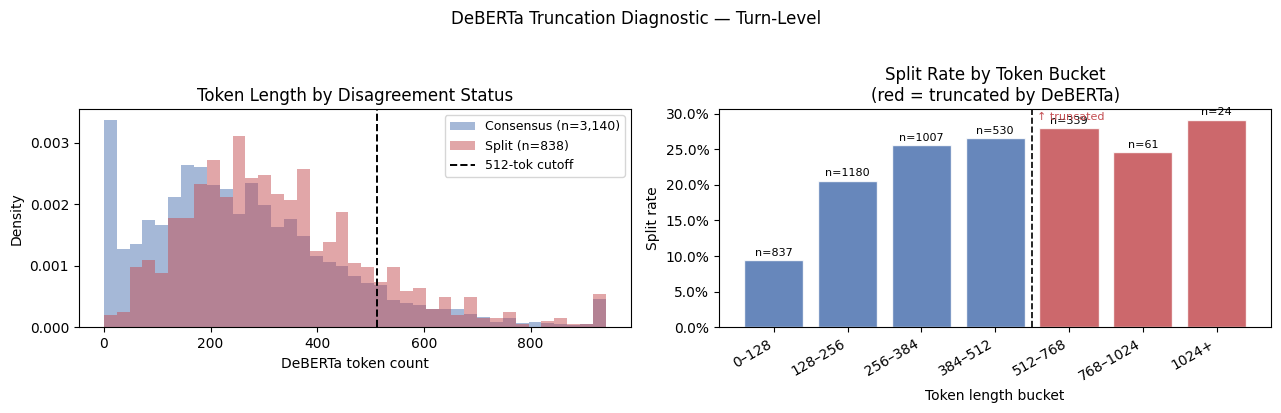

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: overlapping histograms ---
ax = axes[0]
bins = np.linspace(0, turns_wide["n_tokens"].quantile(0.99), 40)
for label, color, group in [
    ("Consensus", "#4C72B0", turns_wide[~turns_wide["split"]]["n_tokens"]),
    ("Split",     "#C44E52", turns_wide[ turns_wide["split"]]["n_tokens"]),
]:
    ax.hist(group.clip(upper=bins[-1]), bins=bins, alpha=0.5, color=color,
            label=f"{label} (n={len(group):,})", density=True)
ax.axvline(MAX_LEN, color="black", linestyle="--", linewidth=1.4, label=f"{MAX_LEN}-tok cutoff")
ax.set_xlabel("DeBERTa token count")
ax.set_ylabel("Density")
ax.set_title("Token Length by Disagreement Status")
ax.legend(fontsize=9)

# --- Right: split rate per token-length bucket ---
ax2 = axes[1]
tok_max = int(turns_wide["n_tokens"].max()) + 1
bins_b  = [0, 128, 256, 384, 512, 768, 1024, tok_max]
labels_b = ["0–128", "128–256", "256–384", "384–512", "512–768", "768–1024", "1024+"]
# Only include labels that have data
turns_wide["token_bin"] = pd.cut(turns_wide["n_tokens"], bins=bins_b,
                                  labels=labels_b, right=False)
bucket = (
    turns_wide.groupby("token_bin", observed=True)["split"]
    .agg(n="count", split_rate="mean")
    .reset_index()
)
TRUNCATED_BINS = {"512–768", "768–1024", "1024+"}
bar_colors = ["#C44E52" if str(b) in TRUNCATED_BINS else "#4C72B0"
              for b in bucket["token_bin"]]
bars = ax2.bar(bucket["token_bin"].astype(str), bucket["split_rate"],
               color=bar_colors, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, bucket.itertuples()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.003,
             f"n={row.n}", ha="center", va="bottom", fontsize=8)

# Dashed vertical line between last full bucket and first truncated bucket
cutoff_x = list(bucket["token_bin"].astype(str)).index("512–768") - 0.5
ax2.axvline(cutoff_x, color="black", linestyle="--", linewidth=1.2)
ax2.text(cutoff_x + 0.07, ax2.get_ylim()[1] * 0.95,
         "↑ truncated", fontsize=8, color="#C44E52")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_xlabel("Token length bucket")
ax2.set_ylabel("Split rate")
ax2.set_title("Split Rate by Token Bucket\n(red = truncated by DeBERTa)")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("DeBERTa Truncation Diagnostic — Turn-Level", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("truncation_diagnostic.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Per-Bank Breakdown

In [6]:
print("Truncation rate per bank:")
print(turns_wide.groupby("bank")["truncated"].mean().map("{:.1%}".format).to_string())

print("\nSplit rate by bank × truncation status:")
bank_tbl = (
    turns_wide.groupby(["bank", "truncated"])
    .agg(n=("split", "count"), split_rate=("split", "mean"))
    .reset_index()
)
bank_tbl["truncated"]  = bank_tbl["truncated"].map({False: "Full", True: "Truncated"})
bank_tbl["split_rate"] = bank_tbl["split_rate"].map("{:.1%}".format)
print(bank_tbl.to_string(index=False))

Truncation rate per bank:
bank
BoE    11.4%
ECB    15.2%
Fed     7.4%

Split rate by bank × truncation status:
bank truncated    n split_rate
 BoE      Full  803      17.4%
 BoE Truncated  103      20.4%
 ECB      Full  985      20.7%
 ECB Truncated  177      29.4%
 Fed      Full 1769      21.4%
 Fed Truncated  141      29.8%


## 6. Per-Speaker-Role Breakdown

Is truncation driven by a particular speaker role?
(Opening statements from governors tend to be longest.)

In [7]:
role_tbl = (
    turns_wide.groupby("speaker_role")
    .agg(
        n          = ("turn_uid", "count"),
        trunc_rate = ("truncated", "mean"),
        split_rate = ("split", "mean"),
        med_tokens = ("n_tokens", "median"),
    )
    .sort_values("trunc_rate", ascending=False)
)
role_tbl["trunc_rate"] = role_tbl["trunc_rate"].map("{:.1%}".format)
role_tbl["split_rate"] = role_tbl["split_rate"].map("{:.1%}".format)
role_tbl["med_tokens"] = role_tbl["med_tokens"].map("{:.0f}".format)
print(role_tbl.to_string())

                 n trunc_rate split_rate med_tokens
speaker_role                                       
president     1162      15.2%      22.0%        278
governor       906      11.4%      17.8%        267
chair         1910       7.4%      22.0%        231


## 7. Mann-Whitney Test — Token Count: Split vs. Consensus

Tests whether split and consensus turns have different token-length distributions,
independently of the 512 threshold.

In [8]:
split_tok    = turns_wide.loc[ turns_wide["split"], "n_tokens"]
nonsplit_tok = turns_wide.loc[~turns_wide["split"], "n_tokens"]

stat, p_mw = mannwhitneyu(split_tok, nonsplit_tok, alternative="two-sided")

print("Token count by disagreement status:")
print(f"  Split     — n={len(split_tok):,}  "
      f"median={split_tok.median():.0f}  mean={split_tok.mean():.0f}")
print(f"  Consensus — n={len(nonsplit_tok):,}  "
      f"median={nonsplit_tok.median():.0f}  mean={nonsplit_tok.mean():.0f}")
print(f"\nMann-Whitney U: stat={stat:.0f},  p={p_mw:.4f}")
if p_mw > 0.05:
    print("→ No significant difference in token length between split and consensus turns.")
else:
    direction = "longer" if split_tok.median() > nonsplit_tok.median() else "shorter"
    print(f"→ Split turns are significantly {direction} than consensus turns (p={p_mw:.4f}).")

Token count by disagreement status:
  Split     — n=838  median=299  mean=330
  Consensus — n=3,140  median=235  mean=267

Mann-Whitney U: stat=1610736,  p=0.0000
→ Split turns are significantly longer than consensus turns (p=0.0000).


## 8. Summary and Interpretation

In [9]:
overall_split    = turns_wide["split"].mean()
trunc_split      = turns_wide.loc[ turns_wide["truncated"], "split"].mean()
full_split       = turns_wide.loc[~turns_wide["truncated"], "split"].mean()
trunc_rate_total = turns_wide["truncated"].mean()
delta            = trunc_split - full_split

print("=" * 62)
print("TRUNCATION DIAGNOSTIC — SUMMARY")
print("=" * 62)
print(f"  Total turns            : {len(turns_wide):,}")
print(f"  Truncated (> 512 tok)  : {turns_wide['truncated'].sum():,}  ({trunc_rate_total:.1%})")
print()
print(f"  Overall split rate     : {overall_split:.1%}")
print(f"  Split rate — full      : {full_split:.1%}")
print(f"  Split rate — truncated : {trunc_split:.1%}")
direction = "HIGHER" if delta > 0 else "LOWER"
print(f"  Delta (trunc − full)   : {delta:+.1%}  ({direction} in truncated)")
print()
if delta < -0.03:
    print("VERDICT: Truncated turns are meaningfully less likely to be split.")
    print("Truncation bites on long, clearly-stanced opening statements.")
    print("ModernBERT robustness check is NOT warranted — truncation is not")
    print("inflating or hiding disagreement where it matters.")
elif abs(delta) <= 0.03:
    print("VERDICT: No meaningful difference in split rates (delta ≤ 3 pp).")
    print("Truncation is essentially random with respect to disagreement.")
    print("ModernBERT robustness check is unlikely to change findings.")
else:
    print("VERDICT: Truncated turns are more likely to be split (+{:.1%})." .format(delta))
    print("Truncation may be suppressing disagreement signal in long turns.")
    print("A longer-context model (e.g. ModernBERT) is worth running as a")
    print("robustness check on the multi-head results.")
print("=" * 62)

TRUNCATION DIAGNOSTIC — SUMMARY
  Total turns            : 3,978
  Truncated (> 512 tok)  : 421  (10.6%)

  Overall split rate     : 21.1%
  Split rate — full      : 20.3%
  Split rate — truncated : 27.3%
  Delta (trunc − full)   : +7.0%  (HIGHER in truncated)

VERDICT: Truncated turns are more likely to be split (+7.0%).
Truncation may be suppressing disagreement signal in long turns.
A longer-context model (e.g. ModernBERT) is worth running as a
robustness check on the multi-head results.
